# Redes neuronales para pronóstico de series de tiempo

## Pregunta del ejercicio

**¿Cuántas denuncias ocurrirán en los próximos meses?**

Este notebook usa una red neuronal para predecir una cantidad numérica mensual, por lo que es un problema de **regresión** y no de clasificación. La idea central es transformar la serie histórica en ejemplos: los últimos 12 meses se usan para predecir el mes siguiente.

> Ejecuta las celdas en orden. Antes de iniciar, cambia `RUTA_DATOS` por la ruta real del archivo Excel descargado del SESNSP.

## Ruta de trabajo

1. Cargar y ordenar la información mensual.
2. Elegir el subtipo delictivo y formar su serie nacional.
3. Construir ventanas deslizantes de 12 meses.
4. Reservar los últimos 2 meses para evaluar el modelo sin usar información futura.
5. Entrenar 20 redes, promediar sus pronósticos y proyectar los meses posteriores.

## 0. Importar librerías

`pandas` organiza los datos, `matplotlib` los grafica y `scikit-learn` aporta la red neuronal, el escalado y las métricas de evaluación.

In [1]:
%pip install pandas numpy matplotlib scikit-learn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [1]:
# PASO 0. IMPORTAR LAS LIBRERÍAS NECESARIAS
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.neural_network import MLPRegressor   # red neuronal para REGRESIÓN
from sklearn.preprocessing import MinMaxScaler    # (predecir un número, no una clase)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# =====================================================================

## 1. Cargar y preparar los datos

La base está en formato ancho: una columna por cada mes. Se convierte a formato largo para tener **un registro por mes**, se construye una fecha y se suman las denuncias de todos los estados y modalidades.

En `DELITO_FILTRO` escribe el nombre exacto de un subtipo mostrado por el catálogo. Usa `None` para trabajar con todos los delitos.

In [2]:
# PASO 1. CARGAR Y PREPARAR LA SERIE DE TIEMPO DE DENUNCIAS DEL SESNSP
# =====================================================================
# Ajusta esta ruta a la ubicación del archivo en tu computadora
# Cambia esta ruta por la ubicación de tu archivo Excel.
RUTA_DATOS = r"datos\Estatal-Delitos-2015-2025_dic2025.xlsx"
delitos_raw = pd.read_excel(RUTA_DATOS)

# ------------------------------------------------------------------
# 1B. Convertir de formato ancho a largo (un registro por mes)
# ------------------------------------------------------------------
MESES = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
         "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

delitos = delitos_raw.melt(
    id_vars=["Año","Clave_Ent","Entidad","Bien jurídico afectado",
             "Tipo de delito","Subtipo de delito","Modalidad"],
    value_vars=MESES,
    var_name="Mes",
    value_name="Denuncias")

# ------------------------------------------------------------------
# 1C. Crear columna de fecha (primer día de cada mes)
# ------------------------------------------------------------------
MESES_NUM = {m: i+1 for i, m in enumerate(MESES)}
delitos["Fecha"] = pd.to_datetime(
    delitos["Año"].astype(str) + "-" +
    delitos["Mes"].map(MESES_NUM).astype(str) + "-01")

# ------------------------------------------------------------------
# 1D. Filtrar por TIPO DELICTIVO (a nivel nacional)
# ------------------------------------------------------------------
# Antes este código filtraba por ESTADO. Ahora lo cambiamos para que
# el análisis sea por TIPO DELICTIVO, sumando todos los estados juntos
# (es decir, a nivel NACIONAL).
#
# OJO con la jerarquía de la base del SESNSP. Cada delito está
# clasificado en tres niveles, de lo más general a lo más específico:
#     "Tipo de delito"     → p.ej. "Homicidio"
#     "Subtipo de delito"  → p.ej. "Homicidio doloso" / "Homicidio culposo"
#     "Modalidad"          → p.ej. "Con arma de fuego", "Con arma blanca", etc
#
# Por ejemplo: "Homicidio doloso" NO es un Tipo, es un SUBTIPO. Por eso 
# filtramos por la columna "Subtipo de delito". Al filtrar por el subtipo, 
# las distintas modalidades (arma de fuego, arma blanca, etc.) se sumarán
# automáticamente en el PASO 1E al agrupar por mes.

# Estas dos líneas imprimen los catálogos para que valides el nombre
# EXACTO que debes escribir (mayúsculas, acentos y espacios importan):
print("\nSubtipos disponibles:")
delitos["Subtipo de delito"].value_counts()

# Elige el subtipo delictivo que quieres analizar.
# Escríbelo EXACTAMENTE como aparece en el catálogo de arriba.
# Para análisis de TODOS los delitos juntos, pon: DELITO_FILTRO = None
DELITO_FILTRO = "Robo a transportista"

if DELITO_FILTRO is not None:
    delitos_filtro = delitos[delitos["Subtipo de delito"] == DELITO_FILTRO].copy()
    etiqueta = f"{DELITO_FILTRO} (Nacional)"
else:
    delitos_filtro = delitos.copy()
    etiqueta = "Todos los delitos (Nacional)"

# ------------------------------------------------------------------
# 1E. Agregar: suma total de denuncias por mes
# Al agrupar por mes sumamos TODOS los estados y TODAS las modalidades
# del subtipo elegido → obtenemos la serie nacional del delito.
# ------------------------------------------------------------------
df = (
    delitos_filtro
    .groupby("Fecha", as_index=False)["Denuncias"]
    .sum()
    .rename(columns={"Fecha": "fecha", "Denuncias": "denuncias"})
    .sort_values("fecha")
    .reset_index(drop=True))

print(f"Serie cargada: {etiqueta}")
print(df.head())
print(f"\nPeriodo: {df['fecha'].min().strftime('%B %Y')} → {df['fecha'].max().strftime('%B %Y')}")
print(f"Total de meses: {len(df)}")
print(f"Denuncias promedio mensual: {df['denuncias'].mean():,.0f}")

# =====================================================================


Subtipos disponibles:
Serie cargada: Robo a transportista (Nacional)
       fecha  denuncias
0 2015-01-01        543
1 2015-02-01        581
2 2015-03-01        595
3 2015-04-01        506
4 2015-05-01        529

Periodo: January 2015 → December 2025
Total de meses: 132
Denuncias promedio mensual: 783


## 2. Explorar la serie

La gráfica permite detectar tendencia, cambios bruscos y posibles patrones anuales antes de entrenar el modelo.

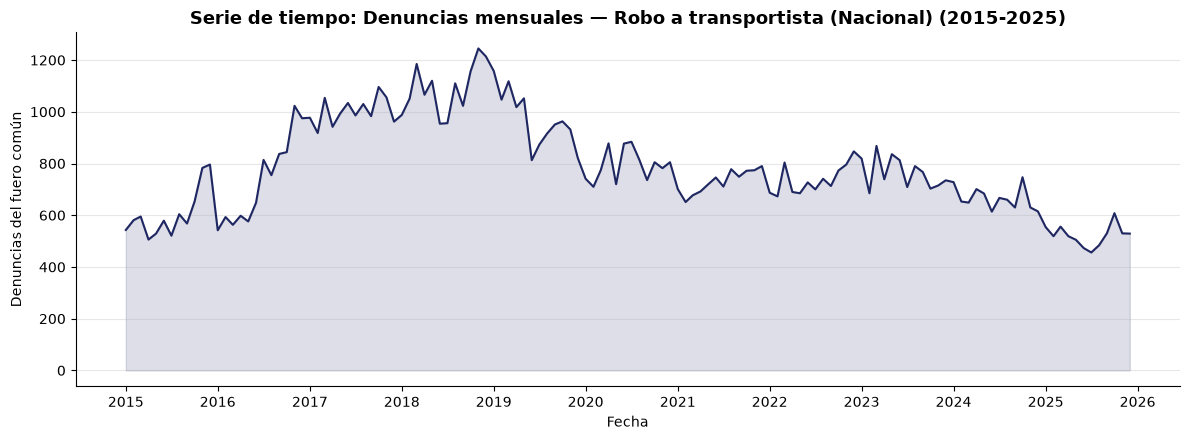

In [3]:
# PASO 2. VISUALIZAR LA SERIE 
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df["fecha"], df["denuncias"], color="#1E2761", linewidth=1.5)
ax.fill_between(df["fecha"], df["denuncias"], alpha=0.15, color="#1E2761")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Fecha")
ax.set_ylabel("Denuncias del fuero común")
ax.set_title(f"Serie de tiempo: Denuncias mensuales — {etiqueta} (2015-2025)",
              fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# =====================================================================

## 3. Crear ventanas deslizantes y separar prueba

Con `W = 12`, cada fila de entrada contiene los 12 meses anteriores y el objetivo es el mes que sigue. Los últimos `N_TEST = 2` meses se reservan para prueba: no participan en el entrenamiento y permiten medir una predicción realista.

In [4]:
# PASO 3. CONVERTIR A SERIE DE TIEMPO Y PREPARAR LOS DATOS
# =====================================================================
FRECUENCIA = 12   # ciclo anual de 12 meses 
N_TEST     = 2    # últimos 2 meses reservados para prueba

# Declaramos la frecuencia mensual explícita en el índice de fechas
serie = df.set_index("fecha")["denuncias"].asfreq("MS")

# Separamos entrenamiento y prueba
serie_train = serie.iloc[:-N_TEST]
serie_test  = serie.iloc[-N_TEST:]

print(f"Serie completa:      {serie.index[0].strftime('%b %Y')} → "
      f"{serie.index[-1].strftime('%b %Y')} ({len(serie)} meses)")
print(f"Entrenamiento:       {serie_train.index[0].strftime('%b %Y')} → "
      f"{serie_train.index[-1].strftime('%b %Y')} ({len(serie_train)} meses)")
print(f"Prueba (reservados): {serie_test.index[0].strftime('%b %Y')} → "
      f"{serie_test.index[-1].strftime('%b %Y')} ({len(serie_test)} meses)")

"""
--- VENTANA DESLIZANTE ---
 W = 12 no significa "entrenar con 12 meses". Significa que para predecir
 cualquier mes, la red usa los 12 meses anteriores como contexto (un ciclo
 anual completo). Pero la red SE ENTRENA con TODOS los ejemplos posibles

   Ejemplo 1:  entrada = meses  1-12  →  objetivo = mes 13
   Ejemplo 2:  entrada = meses  2-13  →  objetivo = mes 14
   Ejemplo 3:  entrada = meses  3-14  →  objetivo = mes 15
   ...
   Ejemplo 118: entrada = meses 119-130 → objetivo = mes 131

 La red ve los 11 años completos, solo que organizados en ventanas
 de 12 meses cada una. No descarta ningún dato histórico,
 solo estructura la información en ventanas del tamaño del ciclo anual.
"""

W = FRECUENCIA  # W = 12, derivado de frequency=12, no es un número arbitrario

valores_train = serie_train.values.astype(float)
X_rows, y_rows = [], []

for i in range(W, len(valores_train)):
    X_rows.append(valores_train[i - W : i])  # los 12 meses anteriores como entrada
    y_rows.append(valores_train[i])          # el mes siguiente como objetivo

X_train = np.array(X_rows)  # shape: (118, 12) — 118 ejemplos, 12 variables cada uno
y_train = np.array(y_rows)  # shape: (118,)

# El conjunto de prueba se construye igual: los 2 meses reservados,
# cada uno usando sus 12 meses anteriores como contexto
X_test = np.array([serie.values[i - W : i] for i in
                   range(len(serie) - N_TEST, len(serie))])
y_test = serie_test.values

print(f"\nVentana W = {W} (un ciclo anual, igual que frequency=12 en R)")
print(f"Ejemplos de entrenamiento generados: {len(X_train)} filas × {W} columnas")
print(f"Ejemplos de prueba:                  {len(X_test)} filas × {W} columnas")


# =====================================================================

Serie completa:      Jan 2015 → Dec 2025 (132 meses)
Entrenamiento:       Jan 2015 → Oct 2025 (130 meses)
Prueba (reservados): Nov 2025 → Dec 2025 (2 meses)

Ventana W = 12 (un ciclo anual, igual que frequency=12 en R)
Ejemplos de entrenamiento generados: 118 filas × 12 columnas
Ejemplos de prueba:                  2 filas × 12 columnas


## 4. Escalar los datos

Las redes neuronales aprenden mejor cuando las variables están en escalas comparables. `MinMaxScaler` lleva los valores al intervalo de 0 a 1. Se ajusta únicamente con entrenamiento para evitar filtración de información del conjunto de prueba.

In [5]:
# PASO 4. ESCALAR LOS DATOS
# Las redes neuronales son sensibles a la escala — igual que vimos en
# el ejercicio de redes neuronales para clasificación. Usamos MinMaxScaler
# (escala entre 0 y 1) en lugar de StandardScaler porque las series de
# tiempo tienen un rango bien definido y no queremos que valores negativos
# confundan al modelo.

# IMPORTANTE: igual que siempre, ajustamos (fit) el escalador SOLO con
# los datos de entrenamiento (118 ejemplos) y luego transformamos tanto
# train como test con esos mismos parámetros — así no se filtra
# información de los 2 meses de prueba hacia el modelo.
# =====================================================================
scaler = MinMaxScaler(feature_range=(0, 1))

X_train_s = scaler.fit_transform(X_train)   # fit + transform sobre entrenamiento
X_test_s  = scaler.transform(X_test)        # solo transform sobre prueba

# El objetivo (y) también hay que escalarlo: la red aprende a predecir
# valores entre 0 y 1, y al final los "desescalamos" con inverse_transform
# para volver a la escala real de denuncias.
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# =====================================================================

## 5. Entrenar un ensamble de redes

Cada red tiene dos capas ocultas de 100 y 50 neuronas. Como la inicialización es aleatoria, se entrenan 20 versiones con semillas distintas y se promedian sus resultados. Esto reduce la variación de depender de una sola red.

La siguiente celda también compara varios tamaños de ensamble. Cuando el MAE deja de bajar de forma apreciable, añadir más redes ya aporta poco.


✅ 20 redes entrenadas
   Arquitectura: 12 entradas → 100 neuronas → 50 neuronas → 1 salida
   Cada red usó una semilla distinta (0 a 19)
   Las predicciones finales serán el PROMEDIO de las 20 redes
reps=   1: MAE = 38
reps=   5: MAE = 12
reps=  10: MAE = 6
reps=  20: MAE = 5
reps=  30: MAE = 7
reps=  40: MAE = 13
reps=  50: MAE = 11
reps=  75: MAE = 10
reps= 100: MAE = 6


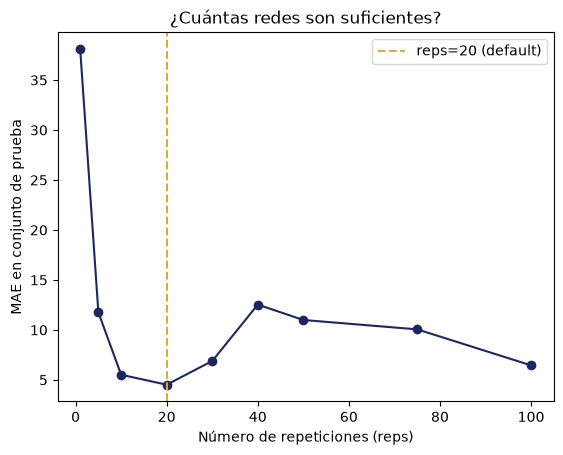

In [6]:
# PASO 5. ENTRENAR LA RED NEURONAL (con múltiples repeticiones)
# REPS entrena 20 redes (con distintas semillas) y promedia sus predicciones 
# para reducir la variabilidad. 
# =====================================================================
REPS = 20          # cuántas redes distintas vamos a entrenar y promediar

# Una red neuronal inicializa sus pesos de forma aleatoria al arrancar.
# Eso significa que si entrenas la misma red dos veces con los mismos
# datos, puede llegar a soluciones ligeramente distintas dependiendo
# de esa inicialización. Entrenar 20 redes con distintas semillas y
# luego PROMEDIAR sus predicciones reduce ese ruido — es el mismo
# principio del Random Forest (muchos modelos distintos votando juntos).

redes_entrenadas = []  # lista donde guardamos cada red ya entrenada

for r in range(REPS):  # r toma valores 0, 1, 2, ... 19

    red = MLPRegressor(

        hidden_layer_sizes=(100, 50),
        # Arquitectura de la red con capas ocultas:
        # Significa: una primera capa oculta de 100 neuronas y una
        # segunda de 50. La capa de entrada tiene W=12 neuronas
        # (una por cada mes de contexto), esto predefinido por W, 
        # y retomado automáticamente al hacer .fit(), según el
        # número de columnas de X_train_s y de y_train_s respectivamente.
        # La salida solo tiene 1 neurona: las denuncias del mes siguiente.

        activation="tanh",
        # Función de activación de cada neurona. Usamos "tanh" en lugar
        # de "logistic" (que usamos en clasificación) porque tanh produce
        # valores entre -1 y 1, centrados en 0, lo que funciona mejor
        # para series de tiempo donde los datos escalados pueden tener
        # variaciones simétricas alrededor de su media.

        max_iter=2000,
        # Número máximo de iteraciones de entrenamiento. Le damos margen 
        # generoso. early_stopping lo detendrá si el modelo converge antes.

        random_state=r,
        # La semilla aleatoria de ESTA repetición. Cada red arranca con
        # pesos iniciales distintos, eso es justamente lo que queremos
        # para luego promediar 20 soluciones diferentes.

        early_stopping=True,
        # Si activamos esto, la red aparta internamente el 10% de los
        # datos de entrenamiento como "validación interna" y monitorea
        # si el error en ese subconjunto deja de mejorar. Cuando ya no
        # mejora durante n_iter_no_change iteraciones seguidas, se
        # detiene sola aunque no haya llegado a max_iter. Esto evita
        # que la red "memorice" los datos de entrenamiento en exceso
        # (sobreajuste).

        validation_fraction=0.1,
        # El 10% de los datos de entrenamiento que se aparta para
        # monitorear si el modelo está mejorando o ya se estancó.

        n_iter_no_change=20
        # Cuántas iteraciones consecutivas sin mejora se toleran antes
        # de detener el entrenamiento anticipadamente.
    )

    red.fit(X_train_s, y_train_s)
    # Aquí ocurre el entrenamiento real: la red ajusta sus pesos internos
    # iteración por iteración hasta minimizar el error entre sus
    # predicciones y los valores reales de y_train_s.

    redes_entrenadas.append(red)
    # Guardamos esta red ya entrenada en la lista. Al terminar el bucle,
    # redes_entrenadas tendrá 20 redes listas para predecir.

print(f"\n✅ {REPS} redes entrenadas")
print(f"   Arquitectura: {W} entradas → 100 neuronas → 50 neuronas → 1 salida")
print(f"   Cada red usó una semilla distinta (0 a {REPS-1})")
print(f"   Las predicciones finales serán el PROMEDIO de las {REPS} redes")

# ¿POR QUÉ 20 REPETICIONES? ¿POR QUÉ NO 100? ¿CUÁL ES EL NÚMERO ÓPTIMO?
# Las redes neuronales son sensibles al punto de inicio aleatorio
# (random_state). Una sola red puede dar resultados muy distintos
# en cada ejecución. La solución: entrenar VARIAS redes y promediar
# sus predicciones (esto se llama "ensamble").

# Pero ¿cuántas redes son suficientes? Demasiado pocas = resultado
# inestable. Demasiadas = costo computacional sin ganancia real.
# Vamos a medirlo: entrenamos ensambles de distinto tamaño y
# comparamos el MAE resultante. Cuando la curva se aplana, ya no
# vale la pena agregar más redes.
reps_a_probar = [1, 5, 10, 20, 30, 40, 50, 75, 100]
errores_por_reps = []

for n_reps in reps_a_probar:
    redes_experimento = []
    for r in range(n_reps):
        red = MLPRegressor(
            hidden_layer_sizes=(100, 50),
            activation="tanh",
            max_iter=2000,
            random_state=r,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20
        )
        red.fit(X_train_s, y_train_s)
        redes_experimento.append(red)

    preds = np.array([
        scaler_y.inverse_transform(
            red.predict(X_test_s).reshape(-1, 1)
        ).ravel()
        for red in redes_experimento
    ]).mean(axis=0)

    errores_por_reps.append(mean_absolute_error(y_test, preds))
    print(f"reps={n_reps:>4}: MAE = {errores_por_reps[-1]:,.0f}")

plt.plot(reps_a_probar, errores_por_reps, marker="o", color="#1E2761")
plt.xlabel("Número de repeticiones (reps)")
plt.ylabel("MAE en conjunto de prueba")
plt.title("¿Cuántas redes son suficientes?")
plt.axvline(20, color="#D4AF37", linestyle="--", label="reps=20 (default)")
plt.legend()
plt.show()

# La gráfica muestra cómo evoluciona el MAE al aumentar el ensemble.
# Busca el punto donde la línea se "aplana": ahí está el óptimo.
# Más reps a la derecha del quiebre = más tiempo, mismo resultado.

# =====================================================================

## 6. Evaluar el desempeño

- **MAE**: error promedio en número de denuncias; es la medida más fácil de interpretar.
- **RMSE**: penaliza con mayor fuerza errores grandes.
- **R²**: proporción de variación explicada; con solo dos observaciones de prueba debe interpretarse con mucha cautela.

In [7]:
# PASO 6. EVALUAR EN EL CONJUNTO DE PRUEBA
# Promediamos las predicciones de las 20 redes antes de evaluar
# =====================================================================
# Predicciones de cada red individual
preds_individuales = np.array([
    scaler_y.inverse_transform(red.predict(X_test_s).reshape(-1, 1)).ravel()
    for red in redes_entrenadas])
preds_individuales
# Promedio del ensemble (las 20 redes juntas)
pred_test = preds_individuales.mean(axis=0)

mae  = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)
mape = np.mean(np.abs((y_test - pred_test) / y_test)) * 100

print("\n" + "="*60)
print("MÉTRICAS DE DESEMPEÑO — Red Neuronal en datos de prueba")
print("="*60)
print(f"MAE  (Error Absoluto Medio):              {mae:,.0f} denuncias")
print(f"RMSE (Raíz del Error Cuadrático Medio):   {rmse:,.0f} denuncias")

print(f"""
LECTURA:
- MAE: en promedio, el modelo tiene rango de error de {mae:,.0f} denuncias al mes.
""")

# =====================================================================


MÉTRICAS DE DESEMPEÑO — Red Neuronal en datos de prueba
MAE  (Error Absoluto Medio):              5 denuncias
RMSE (Raíz del Error Cuadrático Medio):   6 denuncias

LECTURA:
- MAE: en promedio, el modelo tiene rango de error de 5 denuncias al mes.



## 7. Pronosticar meses siguientes

El pronóstico es recursivo: después de predecir un mes, esa predicción entra en la ventana para estimar el siguiente. Los dos primeros meses corresponden a la prueba; los cuatro posteriores son una proyección genuina hacia el futuro.

In [8]:
# PASO 7. PRONOSTICAR 6 MESES DESDE NOVIEMBRE 2025
# Proyectamos nov 2025 → abr 2026 usando como punto de partida los
# últimos W meses de entrenamiento (hasta oct 2025).
# De esos 6 meses, nov y dic 2025 ya los tenemos en los datos reales
# (son nuestros 2 meses de prueba), así que los usaremos para validar.
# Los 4 restantes (ene-abr 2026) son el pronóstico puro hacia el futuro.
# =====================================================================
H = 6  # nov 2025, dic 2025, ene 2026, feb 2026, mar 2026, abr 2026

ventana_actual = serie_train.values[-W:].astype(float).copy()
pronosticos = []

for h in range(H):
    x_nuevo = scaler.transform(ventana_actual.reshape(1, -1))
    pred_h = np.mean([
        scaler_y.inverse_transform(red.predict(x_nuevo).reshape(-1, 1))[0, 0]
        for red in redes_entrenadas
    ])
    pronosticos.append(pred_h)
    ventana_actual = np.append(ventana_actual[1:], pred_h)

fechas_pronostico = pd.date_range(
    start=serie_train.index[-1] + pd.DateOffset(months=1),
    periods=H, freq="MS"
)

print("\n" + "="*60)
print(f"PRONÓSTICO — {H} meses desde noviembre 2025")
print("="*60)
for fecha, valor in zip(fechas_pronostico, pronosticos):
    print(f"  {fecha.strftime('%B %Y'):>20}: {valor:,.0f} denuncias")

# =====================================================================


PRONÓSTICO — 6 meses desde noviembre 2025
         November 2025: 529 denuncias
         December 2025: 521 denuncias
          January 2026: 516 denuncias
         February 2026: 504 denuncias
            March 2026: 492 denuncias
            April 2026: 491 denuncias


## 8. Validar pronóstico contra datos reales

Se comparan noviembre y diciembre de 2025, que el modelo no vio al entrenar, contra sus valores observados. El MAPE resume el error porcentual medio.

In [9]:
# PASO 9. EVALUAR QUÉ TAN BIEN AJUSTÓ EL MODELO EN NOV Y DIC 2025
# Comparamos los primeros 2 meses del pronóstico (nov y dic 2025)
# contra los valores reales que sí tenemos guardados en serie_test.
# =====================================================================
pronosticos_validacion = np.array(pronosticos[:N_TEST])   # nov y dic 2025
reales_validacion      = serie_test.values                 # valores reales

print("\n" + "="*60)
print("VALIDACIÓN — Pronóstico vs. Realidad (nov y dic 2025)")
print("="*60)
print(f"{'Mes':<20} {'Real':>10} {'Pronóstico':>12} {'% Error':>10}")
print("-"*55)
for fecha, real, pron in zip(serie_test.index, reales_validacion, pronosticos_validacion):
    pct_error = abs(real - pron) / real * 100
    print(f"{fecha.strftime('%B %Y'):<20} {real:>10,.0f} {pron:>12,.0f} {pct_error:>9.1f}%")

mape = np.mean(np.abs(reales_validacion - pronosticos_validacion) / reales_validacion * 100)
print(f"\nError porcentual promedio (MAPE): {mape:.1f}%")
print(f"El modelo tiene una precisión promedio de {100-mape:.1f}% (para los 2 meses siguientes)")

# =====================================================================


VALIDACIÓN — Pronóstico vs. Realidad (nov y dic 2025)
Mes                        Real   Pronóstico    % Error
-------------------------------------------------------
November 2025               530          529       0.2%
December 2025               529          521       1.6%

Error porcentual promedio (MAPE): 0.9%
El modelo tiene una precisión promedio de 99.1% (para los 2 meses siguientes)


## 9. Interpretar la gráfica final

La línea azul representa el historial observado. Los puntos dorados muestran las predicciones para los meses de prueba; la línea roja son los meses futuros. La banda roja no es un intervalo estadístico formal: representa la dispersión entre las 20 redes del ensamble, por lo que expresa su desacuerdo relativo.

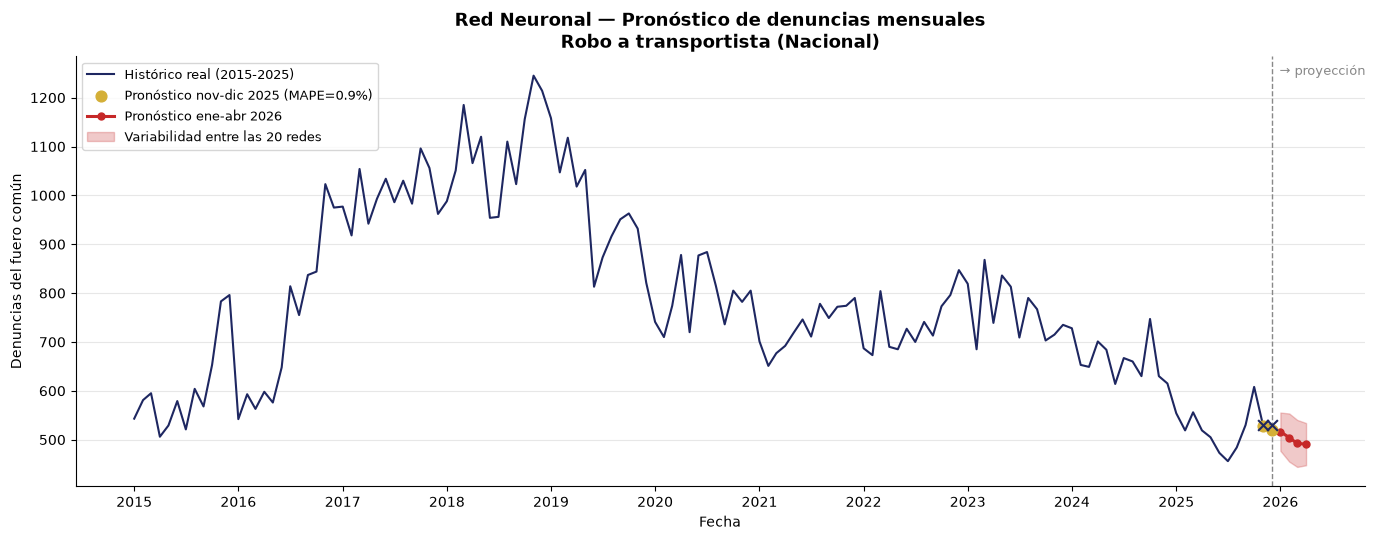

In [10]:
# PASO 10. VISUALIZAR LA SERIE COMPLETA + PRONÓSTICO
# La gráfica muestra:
#   - Serie histórica completa hasta dic 2025 (incluyendo los 2 meses
#     de prueba, para que la línea no tenga un hueco visual)
#   - Los 4 meses proyectados hacia el futuro (ene-abr 2026)
#   - Banda de incertidumbre alrededor de los 4 meses futuros
#     (± 1 desviación estándar entre las predicciones de las 20 redes)
#   - Marcadores en nov y dic 2025 para ver visualmente qué tan bien
#     ajustó el modelo en los meses que sí conocemos
# =====================================================================

# Banda de incertidumbre: recorremos los 6 meses guardando la predicción
# de CADA red (no solo el promedio) para calcular la variabilidad
preds_todas_las_redes = []
ventana_banda = serie_train.values[-W:].astype(float).copy()
for h in range(H):
    x_nuevo = scaler.transform(ventana_banda.reshape(1, -1))
    preds_h = np.array([
        scaler_y.inverse_transform(red.predict(x_nuevo).reshape(-1, 1))[0, 0]
        for red in redes_entrenadas
    ])
    preds_todas_las_redes.append(preds_h)
    ventana_banda = np.append(ventana_banda[1:], preds_h.mean())

preds_todas_las_redes = np.array(preds_todas_las_redes)  # shape (6, 20)

# Solo dibujamos banda en los 4 meses futuros (ene-abr 2026)
fechas_futuro   = fechas_pronostico[N_TEST:]              # ene-abr 2026
prons_futuro    = np.array(pronosticos[N_TEST:])
banda_inf = preds_todas_las_redes[N_TEST:].mean(axis=1) - preds_todas_las_redes[N_TEST:].std(axis=1)
banda_sup = preds_todas_las_redes[N_TEST:].mean(axis=1) + preds_todas_las_redes[N_TEST:].std(axis=1)

fig, ax = plt.subplots(figsize=(14, 5.5))

# Serie histórica completa (entrenamiento + los 2 meses de prueba)
serie_completa = pd.concat([serie_train, serie_test])
ax.plot(serie_completa.index, serie_completa.values,
        color="#1E2761", linewidth=1.5, label="Histórico real (2015-2025)")

# Marcadores de validación: pronóstico vs real en nov y dic 2025
ax.scatter(serie_test.index, pronosticos_validacion,
           color="#D4AF37", zorder=5, s=60,
           label=f"Pronóstico nov-dic 2025 (MAPE={mape:.1f}%)")
ax.scatter(serie_test.index, reales_validacion,
           color="#1E2761", zorder=5, s=60, marker="x")

# Línea de conexión entre real y pronóstico para ver el error visualmente
for fecha, real, pron in zip(serie_test.index, reales_validacion, pronosticos_validacion):
    ax.plot([fecha, fecha], [real, pron],
            color="#D4AF37", linewidth=1.2, linestyle=":")

# Pronóstico puro (ene-abr 2026)
ax.plot(fechas_futuro, prons_futuro,
        color="#C62828", linewidth=2.2, marker="o", markersize=5,
        label="Pronóstico ene-abr 2026")

# Banda de incertidumbre solo en los 4 meses futuros
ax.fill_between(fechas_futuro, banda_inf, banda_sup,
                alpha=0.25, color="#C62828",
                label="Variabilidad entre las 20 redes")

# Línea vertical que separa lo conocido de lo proyectado
ax.axvline(serie_test.index[-1], color="#888888",
           linewidth=1, linestyle="--")
ax.text(serie_test.index[-1], ax.get_ylim()[1] * 0.97,
        "  → proyección", fontsize=9, color="#888888")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Fecha")
ax.set_ylabel("Denuncias del fuero común")
# Usamos la etiqueta del delito (definida en el PASO 1D) para el título
titulo_delito = etiqueta
ax.set_title(f"Red Neuronal — Pronóstico de denuncias mensuales\n{titulo_delito}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# =====================================================================

## 10. Visualizar los pesos de una red

La última figura ilustra la arquitectura entrenada. Azul significa peso positivo, rojo peso negativo y líneas más visibles representan conexiones de mayor magnitud. Es una visualización de una de las redes; el pronóstico final proviene del promedio de las 20.

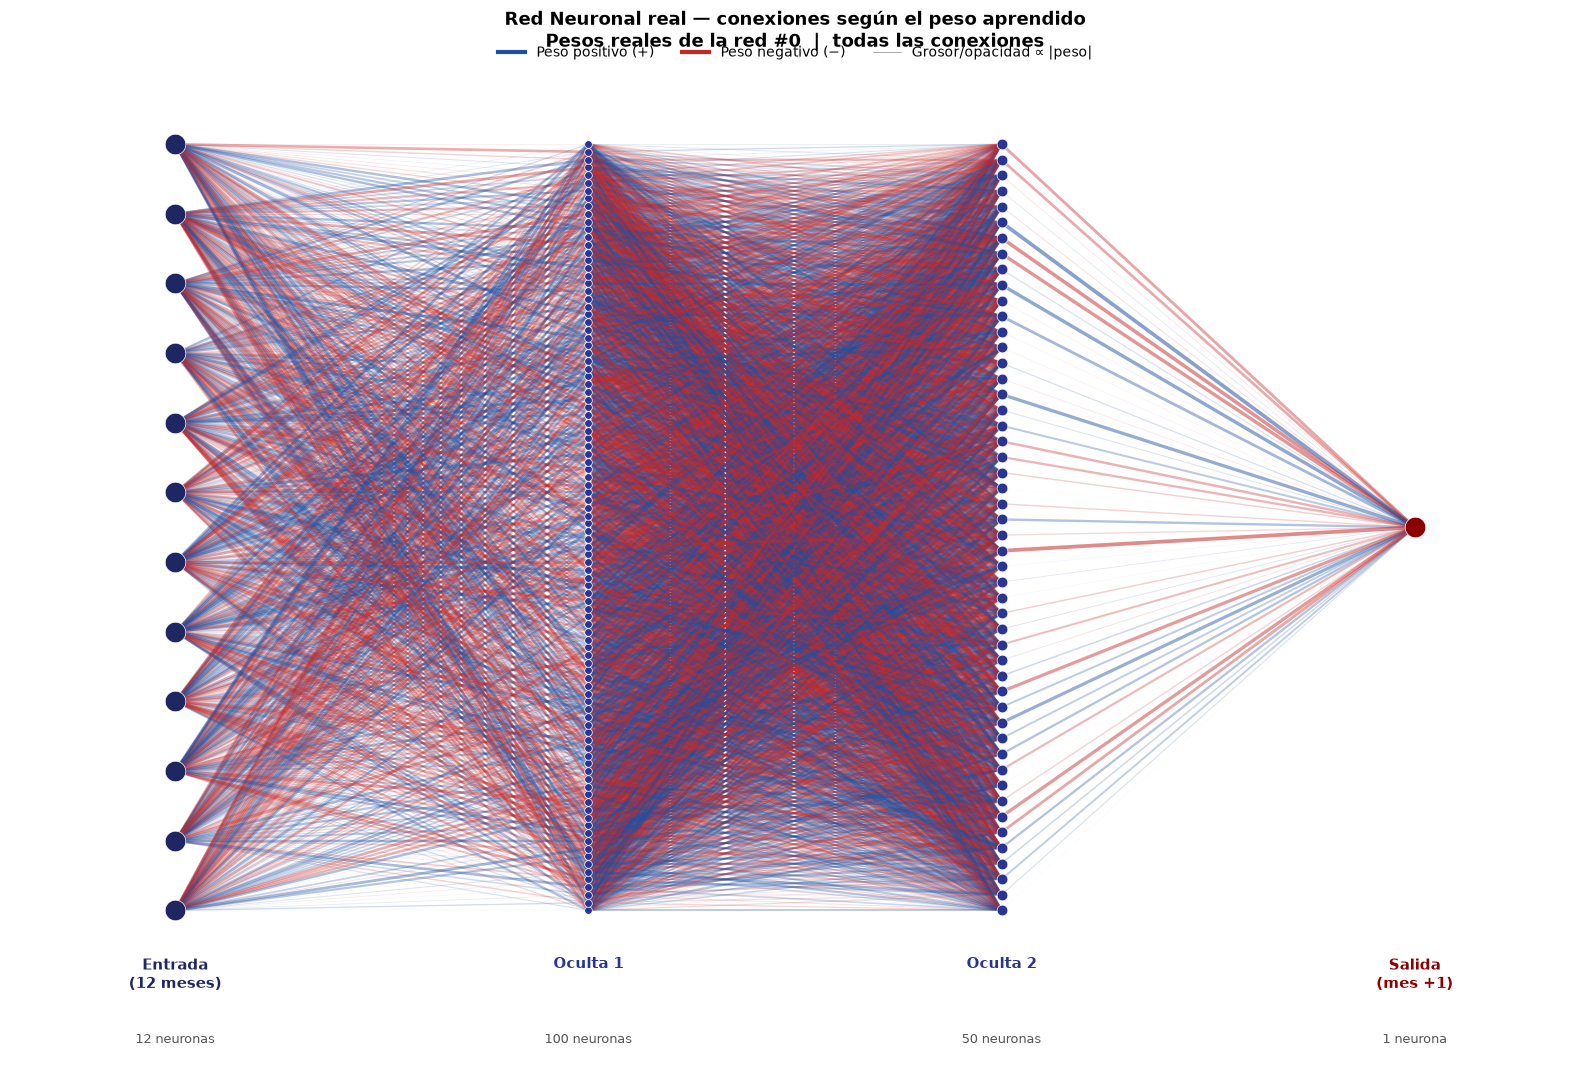

In [11]:
# PASO 11. DIAGRAMAR LA RED NEURONAL REAL (con sus pesos aprendidos)
# Leemos los pesos reales aprendidos (red.coefs_) y los usamos para:
#   - GROSOR de cada línea  → proporcional a |peso|
#   - COLOR de cada línea    → azul = peso positivo, rojo = peso negativo
#   - OPACIDAD               → más opaco = peso más fuerte
#
# CLAVE para que NO se aplaste: en lugar de aspect="equal" (que comprime
# la capa de 100 neuronas en un fideo vertical), normalizamos la altura
# de TODAS las capas al mismo rango [0,1] y usamos una figura ancha.
# =====================================================================

red_ref = redes_entrenadas[0]

pesos = red_ref.coefs_
tam_capas = [pesos[0].shape[0]] + [w.shape[1] for w in pesos]  # [12, 100, 50, 1]

nombres_capas = (
    ["Entrada\n(12 meses)"]
    + [f"Oculta {i+1}" for i in range(len(pesos) - 1)]
    + ["Salida\n(mes +1)"]
)

# PERCENTIL_MIN = 0 dibuja TODO; sube a 80-90 para ver solo las más fuertes
PERCENTIL_MIN = 0

# ---- Posiciones (x, y) de cada neurona ----
# y NORMALIZADA a [0,1] para TODAS las capas → la de 100 y la de 1
# ocupan la misma altura, así nada se aplasta. x con buena separación.
ESPACIO_X = 1.0
ALTO_GRAFICA = 1.0   # todas las capas ocupan esta misma altura vertical

pos_por_capa = []
for c, n in enumerate(tam_capas):
    if n == 1:
        ys = np.array([ALTO_GRAFICA / 2])          # un solo nodo: centrado
    else:
        ys = np.linspace(0, ALTO_GRAFICA, n)        # repartidos de 0 a 1
    x = c * ESPACIO_X
    pos_por_capa.append(np.column_stack([np.full(n, x), ys]))

max_abs_peso = max(np.abs(w).max() for w in pesos)

# Figura ANCHA y alta: aquí está la diferencia. Sin aspect="equal".
fig, ax = plt.subplots(figsize=(16, 11))

# ---- Conexiones (débiles primero, fuertes encima) ----
for c, W_mat in enumerate(pesos):
    izq = pos_por_capa[c]
    der = pos_por_capa[c + 1]

    abs_vals = np.abs(W_mat)
    umbral = np.percentile(abs_vals, PERCENTIL_MIN) if PERCENTIL_MIN > 0 else 0.0

    lineas = []
    for i in range(W_mat.shape[0]):
        for j in range(W_mat.shape[1]):
            peso = W_mat[i, j]
            if abs(peso) < umbral:
                continue
            lineas.append((abs(peso), peso, izq[i], der[j]))

    lineas.sort(key=lambda t: t[0])

    for abs_peso, peso, (x1, y1), (x2, y2) in lineas:
        intensidad = abs_peso / max_abs_peso
        color = "#1E4FA0" if peso >= 0 else "#C62828"
        ax.plot([x1, x2], [y1, y2],
                color=color,
                linewidth=0.2 + 2.5 * intensidad,
                alpha=0.04 + 0.5 * intensidad,
                solid_capstyle="round",
                zorder=1)

# ---- Neuronas encima ----
COLOR_NODO = ["#1E2761"] + ["#283593"] * (len(tam_capas) - 2) + ["#8B0000"]
for c, coords in enumerate(pos_por_capa):
    n = len(coords)
    tam_punto = 220 if n <= 12 else (60 if n <= 60 else 30)
    ax.scatter(coords[:, 0], coords[:, 1],
               s=tam_punto, c=COLOR_NODO[c],
               edgecolors="white", linewidths=0.5, zorder=3)

# ---- Etiquetas debajo de cada capa ----
for c, n in enumerate(tam_capas):
    x = c * ESPACIO_X
    ax.text(x, -0.06, nombres_capas[c],
            ha="center", va="top", fontsize=11, fontweight="bold",
            color=COLOR_NODO[c])
    ax.text(x, -0.16, f"{n} neurona{'s' if n > 1 else ''}",
            ha="center", va="top", fontsize=9.5, color="#555555")

# ---- Leyenda ----
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], color="#1E4FA0", lw=3, label="Peso positivo (+)"),
    Line2D([0], [0], color="#C62828", lw=3, label="Peso negativo (−)"),
    Line2D([0], [0], color="#888888", lw=0.5, label="Grosor/opacidad ∝ |peso|"),
]
ax.legend(handles=leyenda, loc="upper center", ncol=3,
          bbox_to_anchor=(0.5, 1.05), frameon=False, fontsize=10)

subtitulo = ("todas las conexiones" if PERCENTIL_MIN == 0
             else f"mostrando el {100-PERCENTIL_MIN}% de conexiones más fuertes")
ax.set_title("Red Neuronal real — conexiones según el peso aprendido\n"
             + f"Pesos reales de la red #0  |  " + subtitulo,
             fontsize=13, fontweight="bold", pad=26)

# Límites con margen; SIN set_aspect("equal") → usa todo el ancho
ax.set_xlim(-0.4, (len(tam_capas) - 1) * ESPACIO_X + 0.4)
ax.set_ylim(-0.22, ALTO_GRAFICA + 0.08)
ax.axis("off")
plt.tight_layout()
plt.show()

## Conclusión y precauciones

El notebook pronostica a partir del comportamiento pasado de la serie. No incorpora variables externas —por ejemplo, población, operativos, estacionalidad explícita o cambios de registro—, por lo que sus proyecciones deben usarse como una referencia y validarse conforme lleguen nuevos datos. Para comparar modelos, conviene repetir la evaluación con varias ventanas temporales de prueba.